# Fig. 4 — Co-dependent inhibitory plasticity: 수식 유도와 플롯

이 노트북의 목적은 논문 Fig. 4의 **결과 패널만 재현하는 것**이 아니라,  
Fig. 4가 어떤 수식 구조에서 나오는지를 단계별로 플롯하면서 확인하는 것입니다.

Fig. 4의 핵심 질문은 다음입니다.

> 기존 spike-based E/I plasticity는 firing-rate setpoint가 서로 어긋나면 왜 불안정해질 수 있는가?  
> Co-dependent inhibitory plasticity는 왜 firing-rate setpoint가 아니라 **E/I current balance setpoint**로 안정화되는가?

이 노트북은 세 층으로 구성됩니다.

1. 수식 유도: inhibitory plasticity rule에서 `E/I = alpha` 고정점이 나오는 과정
2. 플롯: timing window, E-I balance surface, zero-change line
3. toy dynamics: spike-based I와 co-dependent I를 비교하는 간단한 Fig. 4c/d 스타일 시뮬레이션

마지막에는 업로드한 `ei_balance_brian2.py`를 실제로 연결해 돌리는 optional cell도 포함했습니다.

## 0. Imports and plotting setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

OUTDIR = Path("fig4_outputs")
OUTDIR.mkdir(exist_ok=True)

## 1. Fig. 4의 핵심 구조

논문에서 Fig. 4는 두 가지 inhibitory plasticity를 비교합니다.

### A. Spike-based inhibitory plasticity

Spike-based rule은 보통 postsynaptic firing rate가 어떤 목표 firing rate보다 높으면 inhibitory synapse를 강화하고,  
낮으면 inhibitory synapse를 약화시키는 식으로 동작합니다.

간단히 쓰면,


<p align="center">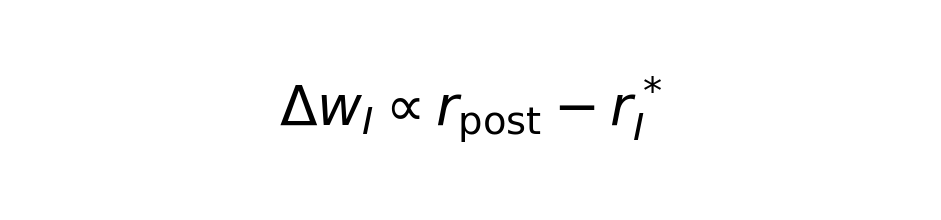</p>


입니다.

반면 excitatory plasticity도 자신의 firing-rate setpoint를 가질 수 있습니다.


<p align="center">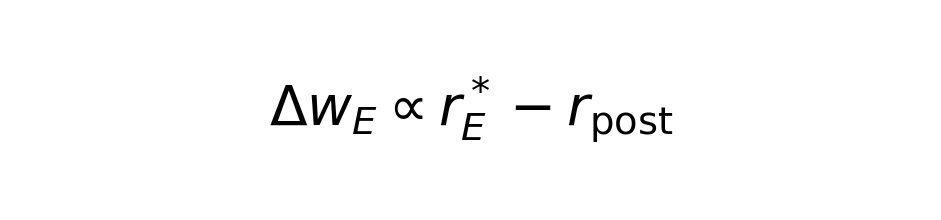</p>


두 setpoint $r_E^*$와 $r_I^*$가 정확히 같으면 괜찮지만,  
서로 달라지면 두 plasticity rule이 서로 다른 목표를 향해 가기 때문에 E/I weight가 drift하거나 collapse할 수 있습니다.

### B. Co-dependent inhibitory plasticity

논문에서 제안한 inhibitory plasticity는 firing rate 자체가 아니라  
근처 synapse들이 만든 excitatory current $E$와 inhibitory current $I$의 비율을 맞춥니다.


<p align="center">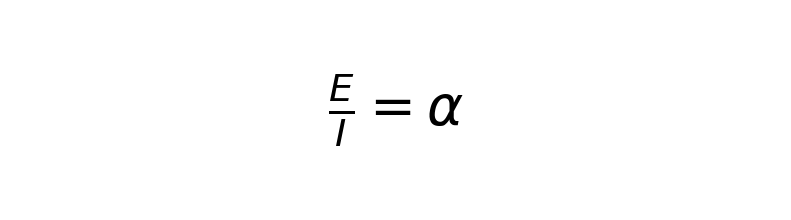</p>


따라서 여러 firing-rate 상태에서도 $E/I$ balance가 맞으면 stable할 수 있습니다.

## 2. Co-dependent inhibitory plasticity rule

논문 Methods의 inhibitory plasticity rule은 다음 형태입니다.


<p align="center">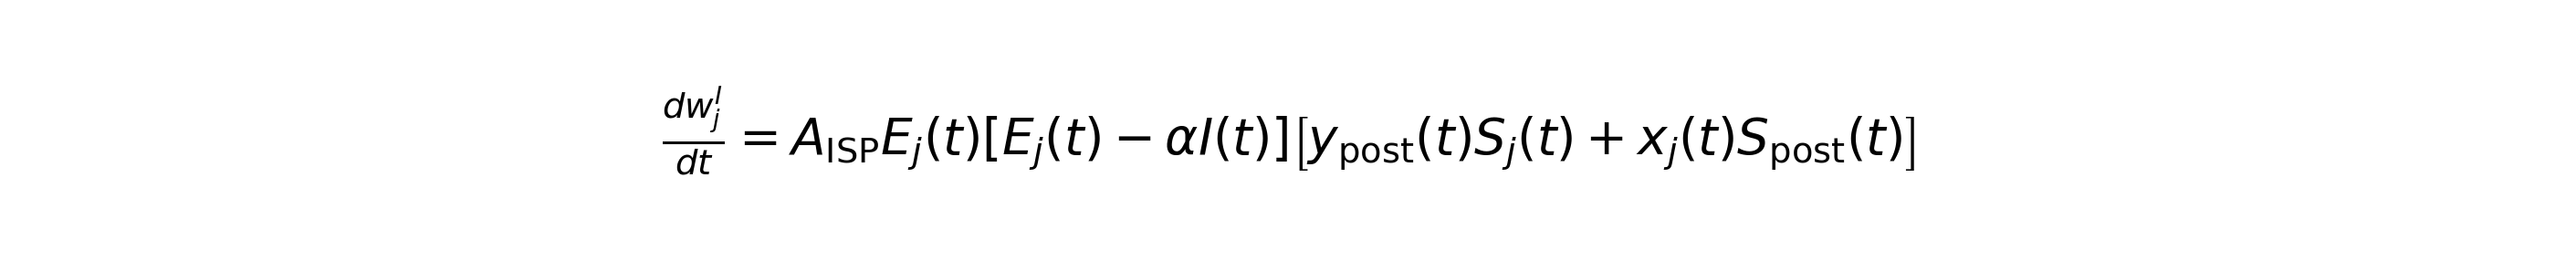</p>


여기서,

- $E_j(t)$: 주변 excitatory synapse들이 만든 NMDA-like current trace
- $I(t)$: 주변 inhibitory synapse들이 만든 GABA-like current trace
- $\alpha$: E/I balance setpoint
- $x_j(t), y_{\mathrm{post}}(t)$: pre/post spike trace
- $S_j(t), S_{\mathrm{post}}(t)$: pre/post spike train

핵심은 두 부분입니다.


<p align="center">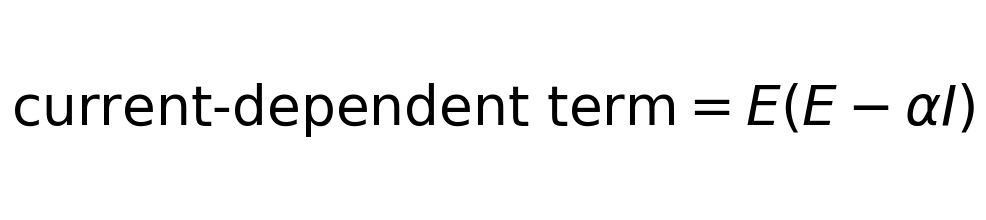</p>



<p align="center">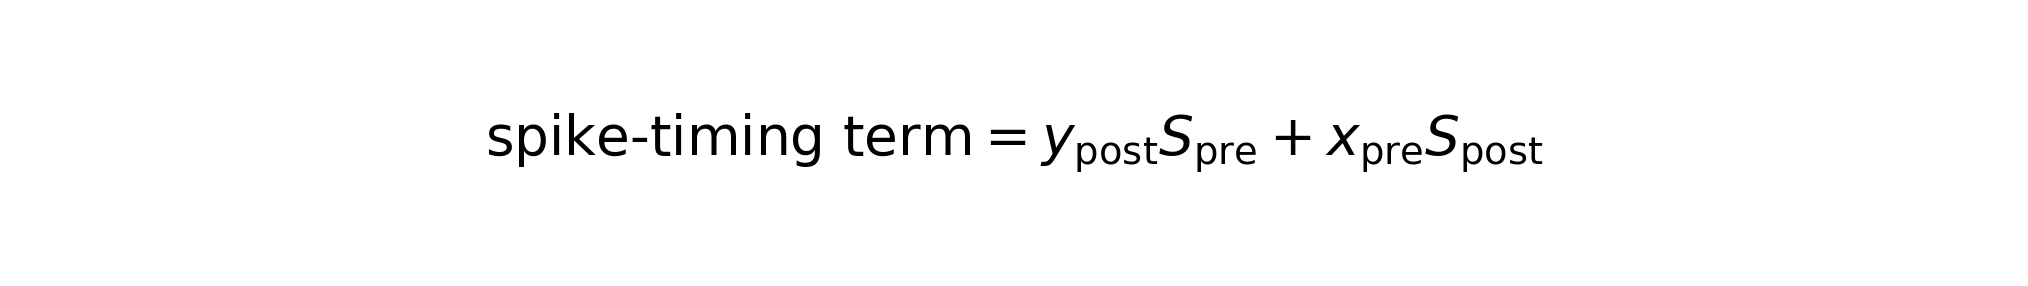</p>


즉, **spike timing은 언제 바꿀지를 정하고**,  
**E/I current term은 어느 방향으로 바꿀지를 정합니다.**

## 3. Spike-timing term: symmetric STDP window

Inhibitory plasticity의 timing term은 pre-before-post와 post-before-pre가 모두 같은 부호로 작용하는 symmetric STDP 형태입니다.

단순화하면,


<p align="center">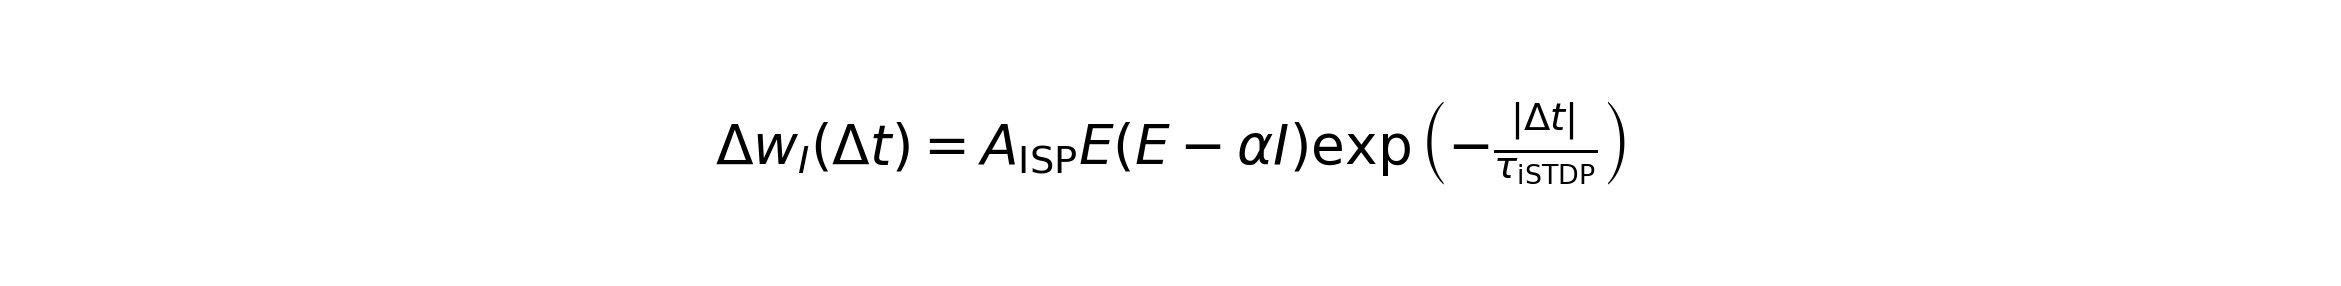</p>


입니다.

여기서 $\Delta t = t_{\mathrm{post}} - t_{\mathrm{pre}}$ 입니다.

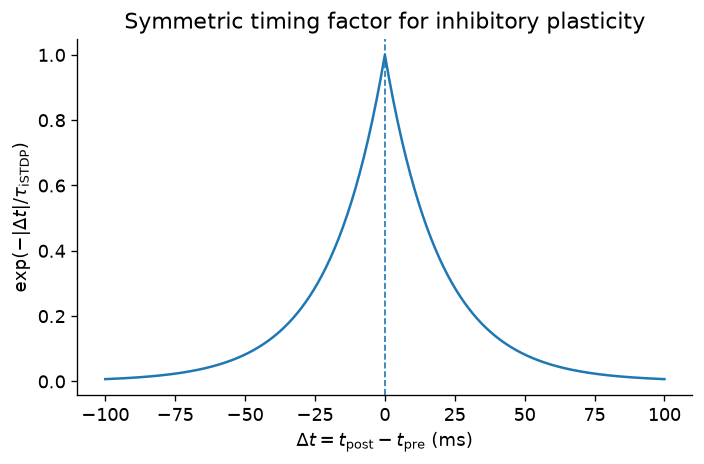

In [2]:
def inhibitory_timing_window(delta_t_ms, tau_i_ms=20.0):
    return np.exp(-np.abs(delta_t_ms) / tau_i_ms)

delta_t = np.linspace(-100, 100, 401)
window = inhibitory_timing_window(delta_t, tau_i_ms=20.0)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(delta_t, window)
ax.axvline(0, linestyle="--", linewidth=1)
ax.set_xlabel(r"$\Delta t = t_{\mathrm{post}} - t_{\mathrm{pre}}$ (ms)")
ax.set_ylabel(r"$\exp(-|\Delta t|/\tau_{\mathrm{iSTDP}})$")
ax.set_title("Symmetric timing factor for inhibitory plasticity")
fig.tight_layout()
fig.savefig(OUTDIR / "01_symmetric_timing_window.png")
plt.show()

위 플롯에서 중요한 점은 다음입니다.

- $\Delta t > 0$, 즉 pre-before-post도 영향을 줍니다.
- $\Delta t < 0$, 즉 post-before-pre도 영향을 줍니다.
- 부호는 timing이 아니라 $E(E-\alpha I)$가 결정합니다.

## 4. Current-dependent term: $E(E-\alpha I)$

이제 spike timing을 잠시 고정하고, current-dependent term만 보겠습니다.


<p align="center">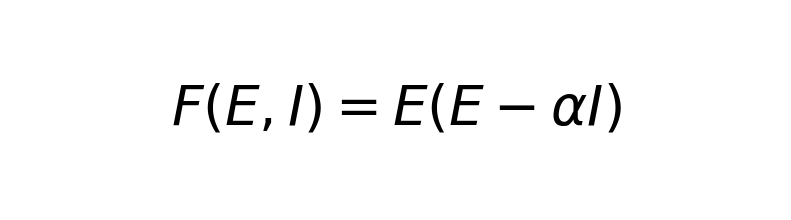</p>


이 항은 다음 성질을 가집니다.

1. $E=0$이면 변화 없음  

<p align="center">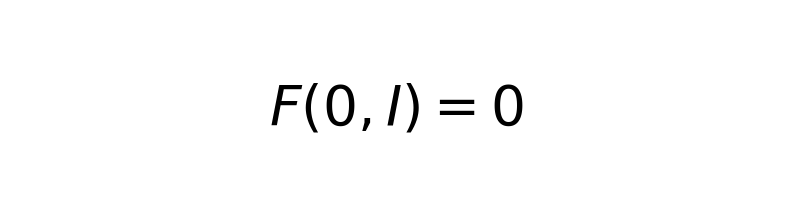</p>


2. $E=\alpha I$이면 변화 없음  

<p align="center">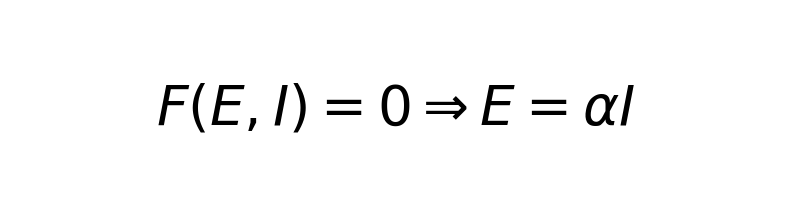</p>


3. $E>\alpha I$이면 inhibitory LTP  

<p align="center">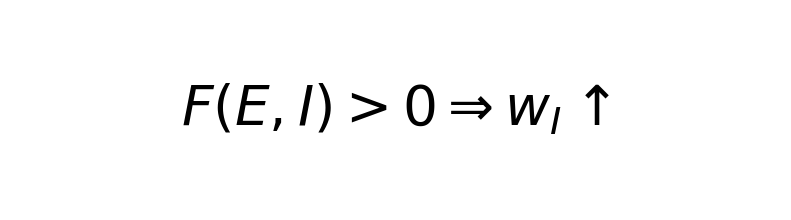</p>


4. $E<\alpha I$이면 inhibitory LTD  

<p align="center">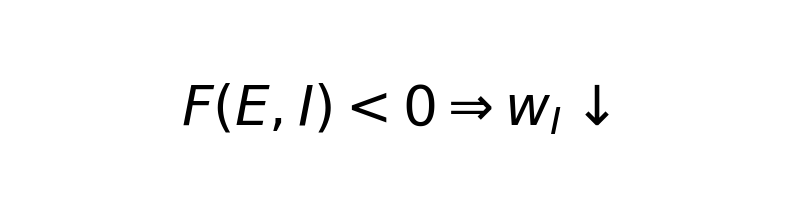</p>


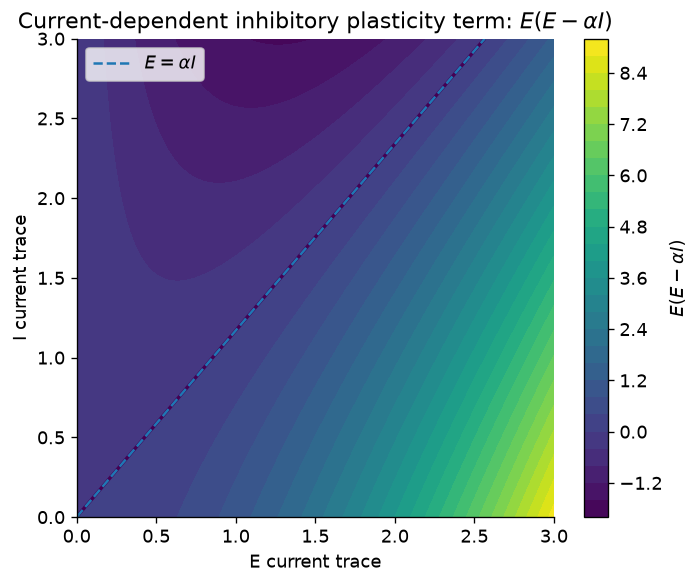

In [3]:
alpha = 0.855

E_vals = np.linspace(0, 3.0, 200)
I_vals = np.linspace(0, 3.0, 200)
E_grid, I_grid = np.meshgrid(E_vals, I_vals)

F = E_grid * (E_grid - alpha * I_grid)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.contourf(E_grid, I_grid, F, levels=31)
ax.contour(E_grid, I_grid, F, levels=[0], linewidths=2)
ax.plot(alpha * I_vals, I_vals, linestyle="--", label=r"$E=\alpha I$")
ax.set_xlabel("E current trace")
ax.set_ylabel("I current trace")
ax.set_title(r"Current-dependent inhibitory plasticity term: $E(E-\alpha I)$")
ax.legend()
fig.colorbar(im, ax=ax, label=r"$E(E-\alpha I)$")
fig.tight_layout()
fig.savefig(OUTDIR / "02_current_balance_surface.png")
plt.show()

이 플롯이 Fig. 4의 가장 중요한 수식적 기반입니다.

- contour의 zero line이 $E=\alpha I$ 입니다.
- 이 선보다 $E$가 크면 $w_I$가 증가해서 inhibition이 강해집니다.
- 이 선보다 $E$가 작으면 $w_I$가 감소해서 inhibition이 약해집니다.

즉, 이 rule은 firing rate 자체가 아니라  
**E/I current ratio**를 $\alpha$로 맞추는 방향으로 작동합니다.

## 5. 평균 dynamics로부터 fixed point 유도

Spike train을 시간 평균 firing rate로 근사하면,


<p align="center">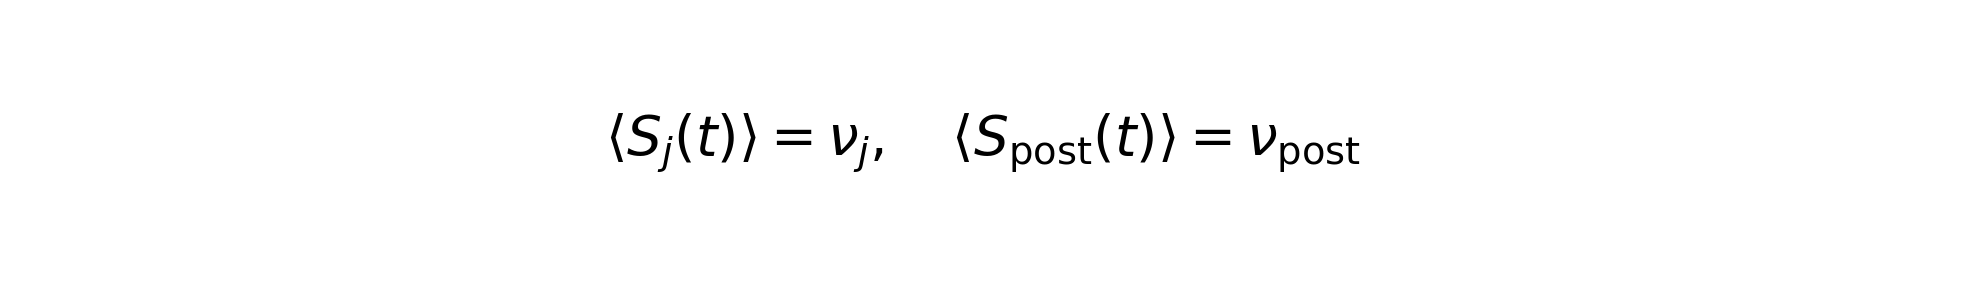</p>


pre/post traces도 평균적으로 firing rate에 비례합니다.


<p align="center">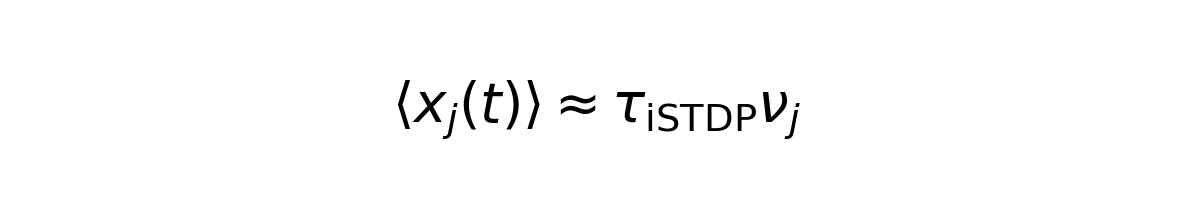</p>



<p align="center">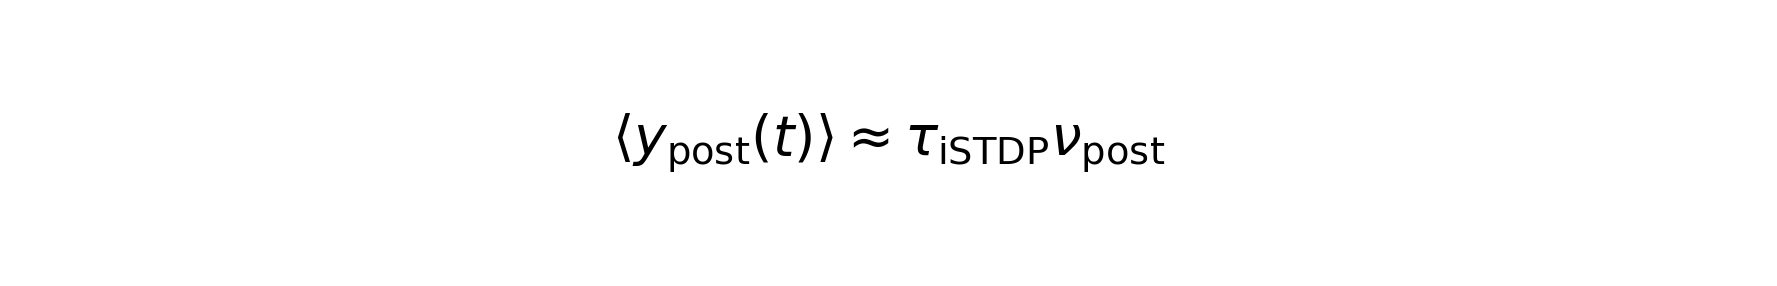</p>


따라서 inhibitory weight 변화의 평균은 다음처럼 쓸 수 있습니다.


<p align="center">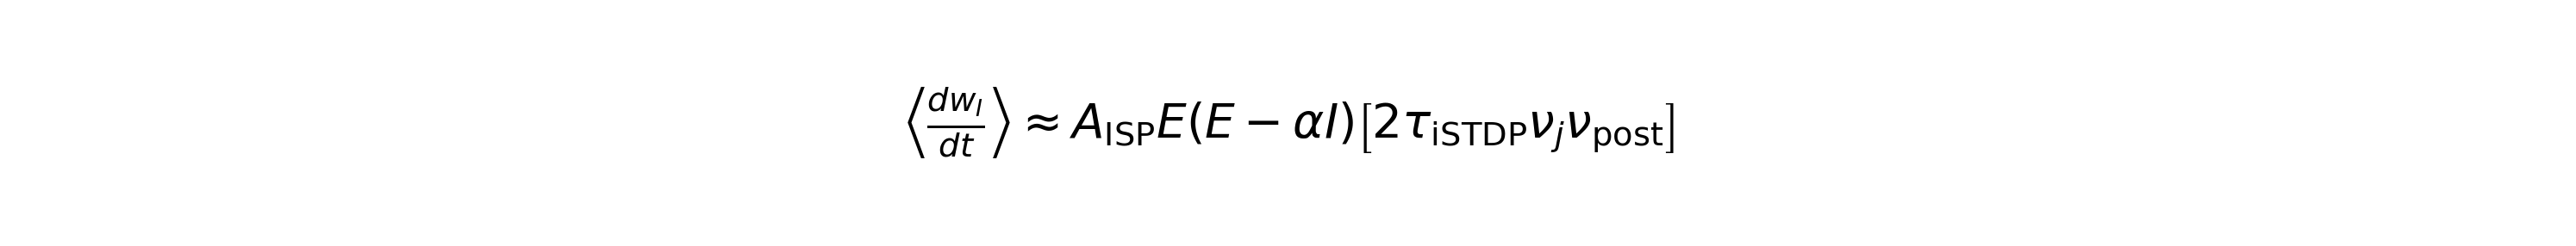</p>


여기서 spike-rate factor는 양수입니다.


<p align="center">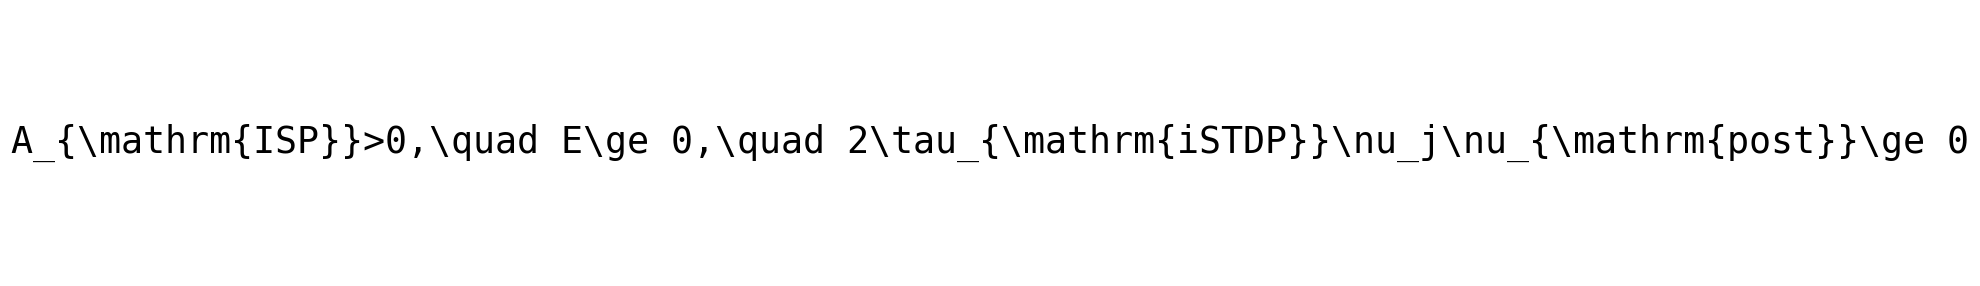</p>


따라서 fixed point는 다음 조건에서 생깁니다.


<p align="center">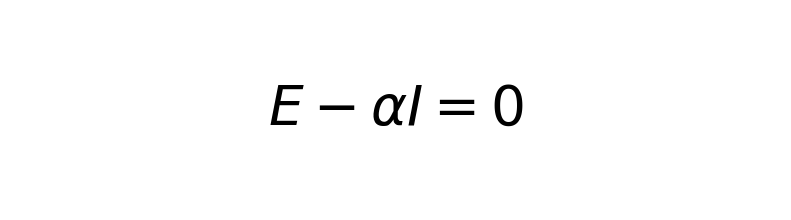</p>


즉,


<p align="center">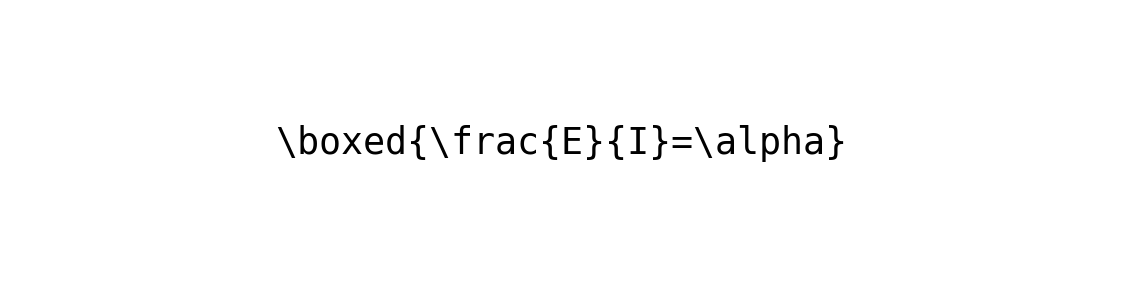</p>


이것이 Fig. 4d의 핵심입니다.

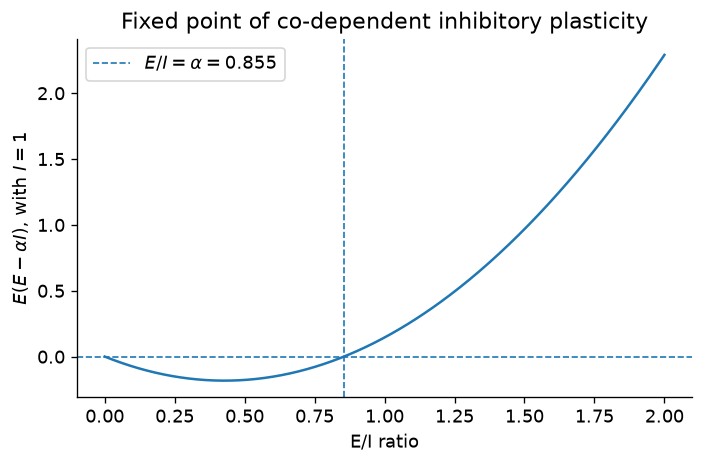

In [4]:
ratio = np.linspace(0, 2.0, 400)
I_fixed = 1.0
E_from_ratio = ratio * I_fixed
drive_ratio = E_from_ratio * (E_from_ratio - alpha * I_fixed)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ratio, drive_ratio)
ax.axhline(0, linestyle="--", linewidth=1)
ax.axvline(alpha, linestyle="--", linewidth=1, label=fr"$E/I=\alpha={alpha}$")
ax.set_xlabel("E/I ratio")
ax.set_ylabel(r"$E(E-\alpha I)$, with $I=1$")
ax.set_title("Fixed point of co-dependent inhibitory plasticity")
ax.legend()
fig.tight_layout()
fig.savefig(OUTDIR / "03_ei_ratio_fixed_point.png")
plt.show()

## 6. Spike-based setpoint mismatch: Fig. 4b intuition

Spike-based excitatory rule과 spike-based inhibitory rule을 아주 단순화해서 다음처럼 쓰겠습니다.


<p align="center">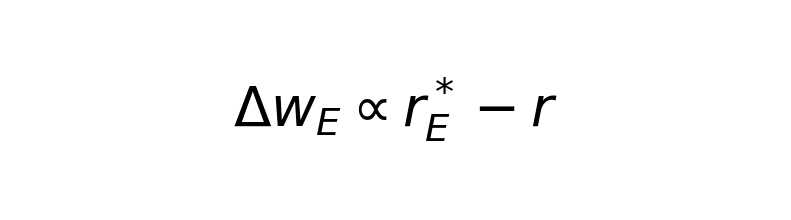</p>



<p align="center">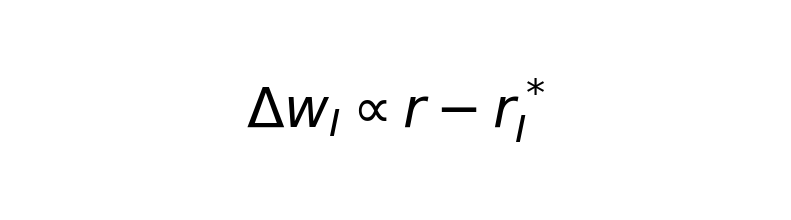</p>


여기서 $r_E^*$와 $r_I^*$는 각각 excitatory rule과 inhibitory rule이 암묵적으로 강제하는 firing-rate setpoint입니다.

문제는 $r_E^*\ne r_I^*$일 때입니다.  
두 rule이 서로 다른 firing-rate 목표를 가지므로, synaptic weights가 서로 밀고 당기면서 불안정해질 수 있습니다.

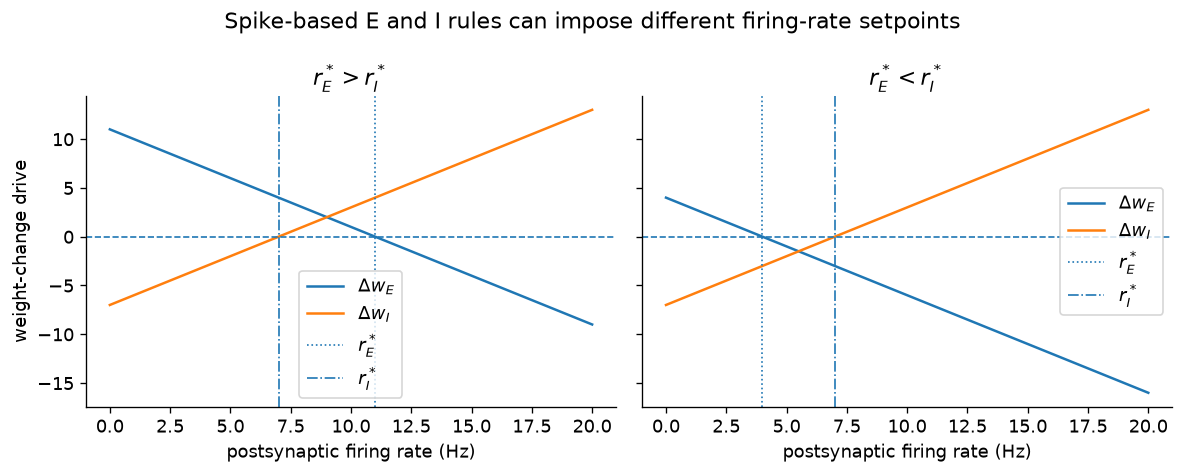

In [5]:
r = np.linspace(0, 20, 400)

def delta_wE_spike_rate(r, rE_star):
    return rE_star - r

def delta_wI_spike_rate(r, rI_star):
    return r - rI_star

cases = [
    {"rE_star": 11.0, "rI_star": 7.0, "title": r"$r_E^* > r_I^*$"},
    {"rE_star": 4.0, "rI_star": 7.0, "title": r"$r_E^* < r_I^*$"},
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, case in zip(axes, cases):
    dE = delta_wE_spike_rate(r, case["rE_star"])
    dI = delta_wI_spike_rate(r, case["rI_star"])
    ax.plot(r, dE, label=r"$\Delta w_E$")
    ax.plot(r, dI, label=r"$\Delta w_I$")
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.axvline(case["rE_star"], linestyle=":", linewidth=1, label=r"$r_E^*$")
    ax.axvline(case["rI_star"], linestyle="-.", linewidth=1, label=r"$r_I^*$")
    ax.set_xlabel("postsynaptic firing rate (Hz)")
    ax.set_title(case["title"])
    ax.legend()

axes[0].set_ylabel("weight-change drive")
fig.suptitle("Spike-based E and I rules can impose different firing-rate setpoints")
fig.tight_layout()
fig.savefig(OUTDIR / "04_spike_based_setpoint_mismatch.png")
plt.show()

위 그림은 Fig. 4b의 논리를 단순화한 것입니다.

- $r_E^*$와 $r_I^*$가 같으면 한 점으로 수렴할 수 있습니다.
- $r_E^*$와 $r_I^*$가 다르면, 한 plasticity rule은 LTP를 요구하고 다른 rule은 LTD를 요구하는 구간이 생깁니다.
- 그래서 Fig. 4c처럼 E/I weight가 함께 안정된 balance를 유지하지 못할 수 있습니다.

반면 co-dependent inhibitory plasticity는 firing-rate setpoint를 직접 만들지 않고,


<p align="center">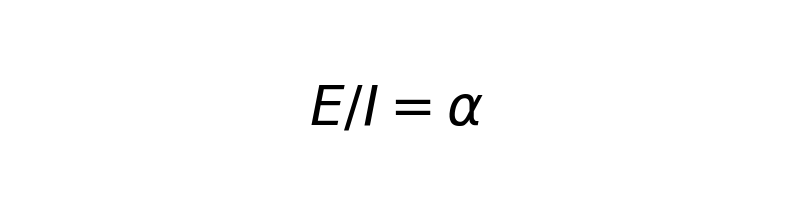</p>


라는 current-balance setpoint를 만듭니다.

## 7. Toy time-course simulation

이제 아주 단순한 rate model로 Fig. 4c/d의 개념을 보겠습니다.

이 toy model은 논문의 full Brian2 simulation이 아닙니다.  
목적은 수식의 방향성을 눈으로 확인하는 것입니다.

### 공통 구조


<p align="center">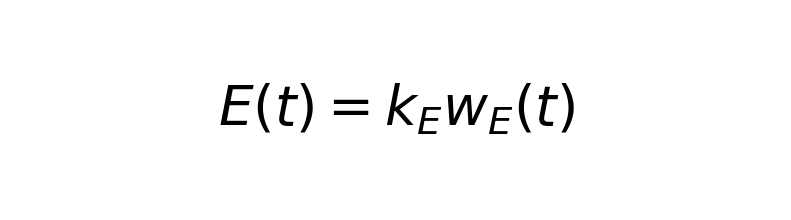</p>



<p align="center">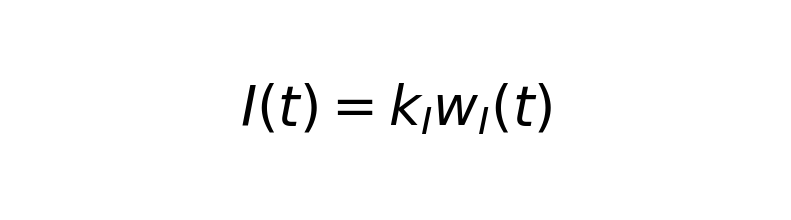</p>



<p align="center">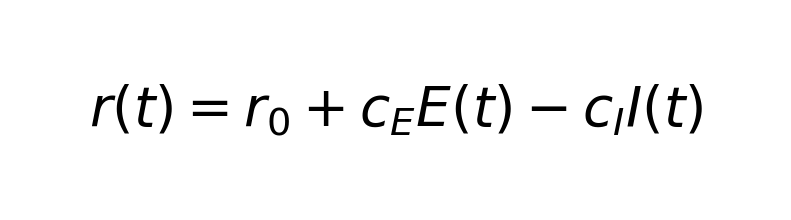</p>


Excitatory plasticity는 spike-based setpoint를 따른다고 놓습니다.


<p align="center">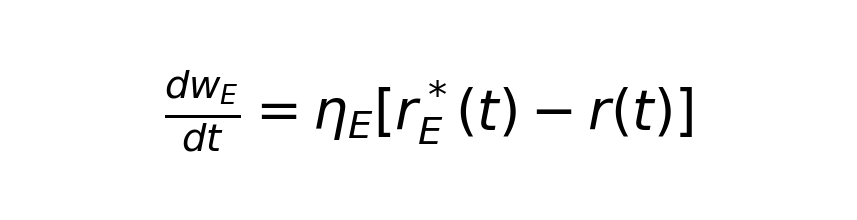</p>


### Case 1: spike-based inhibitory plasticity


<p align="center">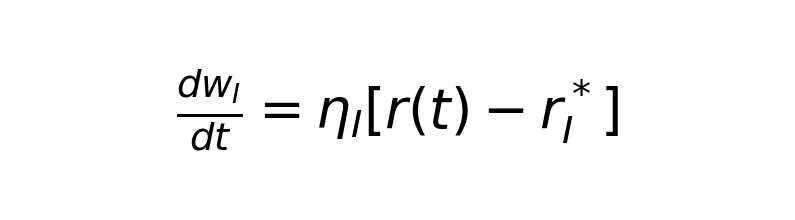</p>


### Case 2: co-dependent inhibitory plasticity


<p align="center">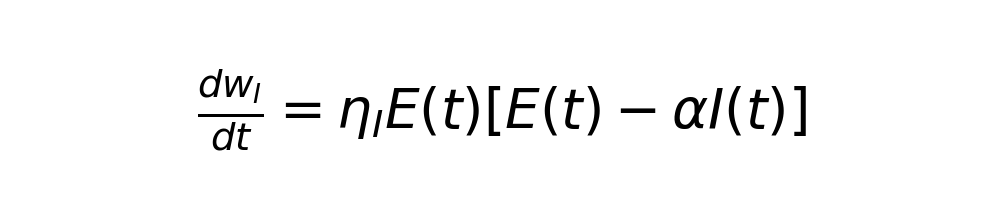</p>


이제 $r_E^*(t)$를 4개 block으로 바꿔보겠습니다.


<p align="center">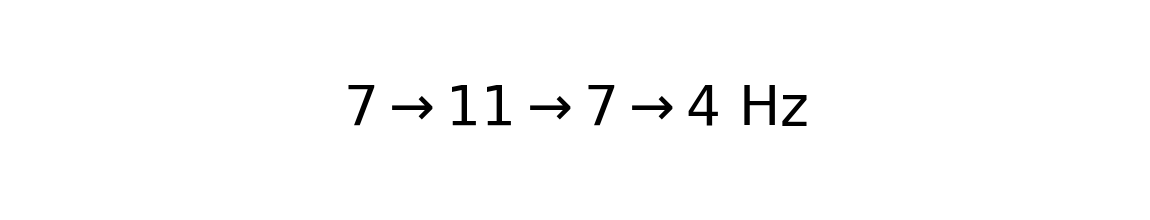</p>


이 구조는 업로드한 `ei_balance_brian2.py`의 `target_rate_schedule()`과 같은 아이디어입니다.

In [6]:
def simulate_toy_fig4(rule="spike_i", total_min=50.0, dt_min=0.01, alpha=0.855):
    n = int(total_min / dt_min)
    t = np.arange(n) * dt_min

    block_edges = np.linspace(0, total_min, 5)
    rE_targets = np.zeros(n)
    for i, target in enumerate([7.0, 11.0, 7.0, 4.0]):
        mask = (t >= block_edges[i]) & (t < block_edges[i + 1])
        rE_targets[mask] = target

    rI_star = 7.0

    # weights and model constants
    wE = np.zeros(n)
    wI = np.zeros(n)
    E = np.zeros(n)
    I = np.zeros(n)
    ratio = np.zeros(n)
    r = np.zeros(n)

    wE[0] = 1.0
    wI[0] = 1.0

    kE = 1.0
    kI = 1.0
    r0 = 7.0
    cE = 3.0
    cI = 3.0

    etaE = 0.015
    etaI_spike = 0.018
    etaI_codep = 0.010

    for i in range(n - 1):
        E[i] = kE * wE[i]
        I[i] = kI * wI[i]
        ratio[i] = E[i] / (I[i] + 1e-12)
        r[i] = np.clip(r0 + cE * (E[i] - 1.0) - cI * (I[i] - 1.0), 0.0, 30.0)

        d_wE = etaE * (rE_targets[i] - r[i])

        if rule == "spike_i":
            d_wI = etaI_spike * (r[i] - rI_star)
        elif rule == "codep_i":
            d_wI = etaI_codep * E[i] * (E[i] - alpha * I[i])
        else:
            raise ValueError("rule must be spike_i or codep_i")

        wE[i + 1] = np.clip(wE[i] + dt_min * d_wE, 0.05, 5.0)
        wI[i + 1] = np.clip(wI[i] + dt_min * d_wI, 0.05, 5.0)

    E[-1] = kE * wE[-1]
    I[-1] = kI * wI[-1]
    ratio[-1] = E[-1] / (I[-1] + 1e-12)
    r[-1] = np.clip(r0 + cE * (E[-1] - 1.0) - cI * (I[-1] - 1.0), 0.0, 30.0)

    return pd.DataFrame({
        "time_min": t,
        "r": r,
        "rE_target": rE_targets,
        "rI_target": rI_star,
        "wE": wE,
        "wI": wI,
        "E": E,
        "I": I,
        "E_over_I": ratio,
        "rule": rule,
    })

df_spike = simulate_toy_fig4(rule="spike_i")
df_codep = simulate_toy_fig4(rule="codep_i")

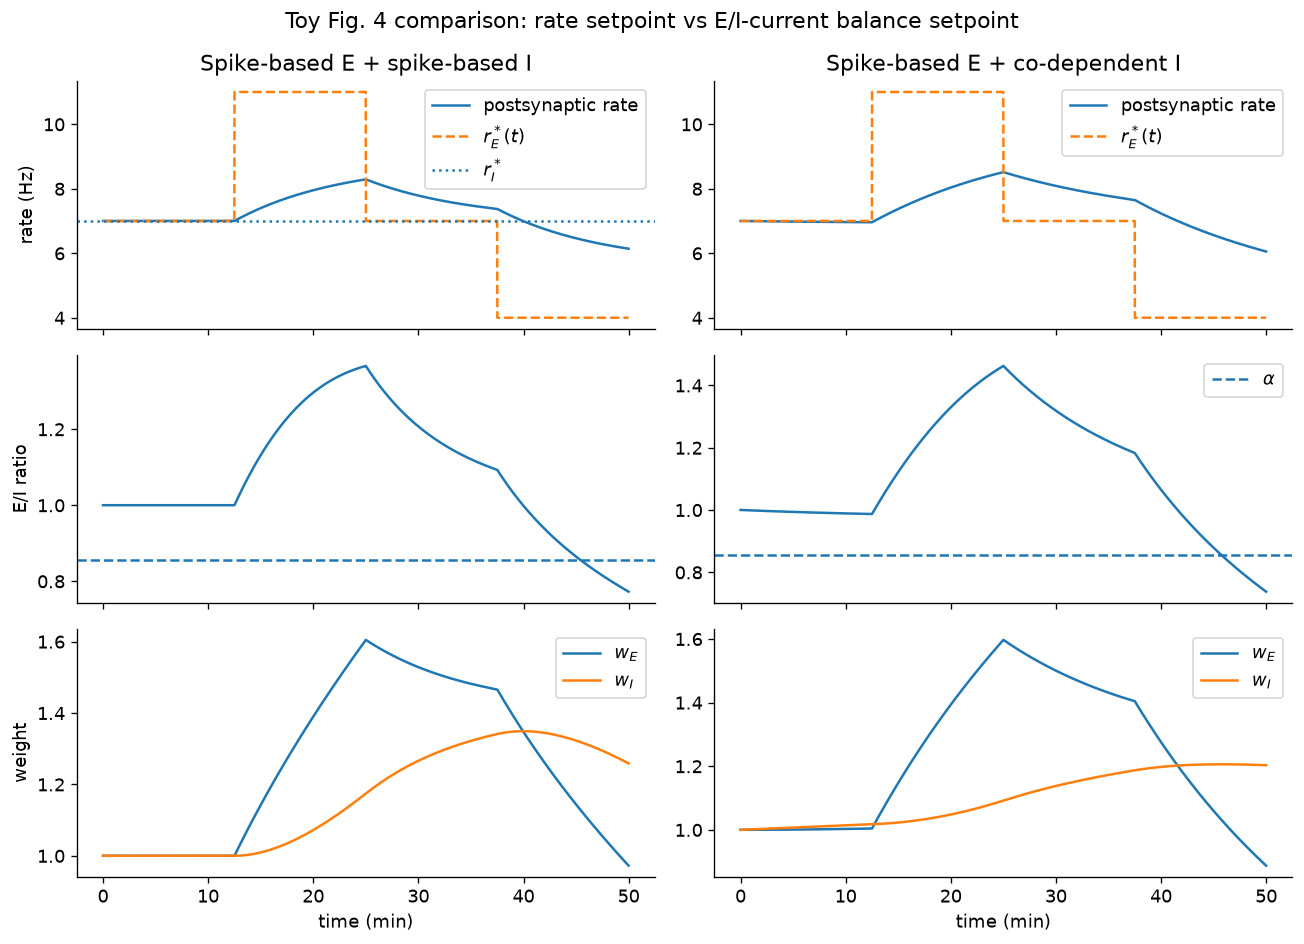

In [7]:
def plot_toy_comparison(df_spike, df_codep, alpha=0.855):
    fig, axes = plt.subplots(3, 2, figsize=(11, 8), sharex=True)

    # firing rate
    axes[0, 0].plot(df_spike["time_min"], df_spike["r"], label="postsynaptic rate")
    axes[0, 0].plot(df_spike["time_min"], df_spike["rE_target"], linestyle="--", label=r"$r_E^*(t)$")
    axes[0, 0].axhline(df_spike["rI_target"].iloc[0], linestyle=":", label=r"$r_I^*$")
    axes[0, 0].set_title("Spike-based E + spike-based I")
    axes[0, 0].set_ylabel("rate (Hz)")
    axes[0, 0].legend()

    axes[0, 1].plot(df_codep["time_min"], df_codep["r"], label="postsynaptic rate")
    axes[0, 1].plot(df_codep["time_min"], df_codep["rE_target"], linestyle="--", label=r"$r_E^*(t)$")
    axes[0, 1].set_title("Spike-based E + co-dependent I")
    axes[0, 1].legend()

    # E/I ratio
    axes[1, 0].plot(df_spike["time_min"], df_spike["E_over_I"])
    axes[1, 0].axhline(alpha, linestyle="--")
    axes[1, 0].set_ylabel("E/I ratio")

    axes[1, 1].plot(df_codep["time_min"], df_codep["E_over_I"])
    axes[1, 1].axhline(alpha, linestyle="--", label=r"$\alpha$")
    axes[1, 1].legend()

    # weights
    axes[2, 0].plot(df_spike["time_min"], df_spike["wE"], label=r"$w_E$")
    axes[2, 0].plot(df_spike["time_min"], df_spike["wI"], label=r"$w_I$")
    axes[2, 0].set_ylabel("weight")
    axes[2, 0].set_xlabel("time (min)")
    axes[2, 0].legend()

    axes[2, 1].plot(df_codep["time_min"], df_codep["wE"], label=r"$w_E$")
    axes[2, 1].plot(df_codep["time_min"], df_codep["wI"], label=r"$w_I$")
    axes[2, 1].set_xlabel("time (min)")
    axes[2, 1].legend()

    fig.suptitle("Toy Fig. 4 comparison: rate setpoint vs E/I-current balance setpoint")
    fig.tight_layout()
    fig.savefig(OUTDIR / "05_toy_fig4_comparison.png")
    plt.show()

plot_toy_comparison(df_spike, df_codep, alpha=alpha)

## 8. Fig. 4 해석

### 1단계: 기존 spike-based E/I plasticity의 문제

Spike-based excitatory plasticity와 spike-based inhibitory plasticity는 각각 firing-rate setpoint를 만들 수 있습니다.  
하지만 두 setpoint가 항상 같다는 보장이 없습니다.


<p align="center">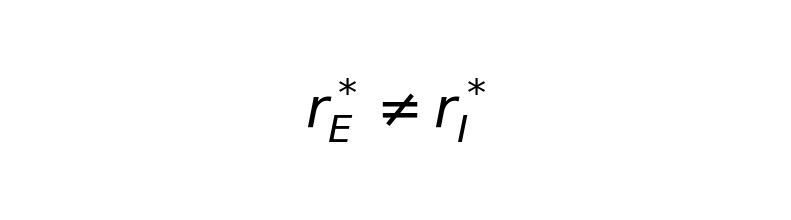</p>


그러면 E synapse와 I synapse가 서로 다른 목표를 향해 변하면서,  
weight가 drift하거나 balance가 깨질 수 있습니다.

### 2단계: co-dependent inhibitory plasticity의 핵심

Co-dependent inhibitory plasticity는 firing-rate setpoint를 직접 강제하지 않습니다.  
대신 E/I current ratio를 맞춥니다.


<p align="center">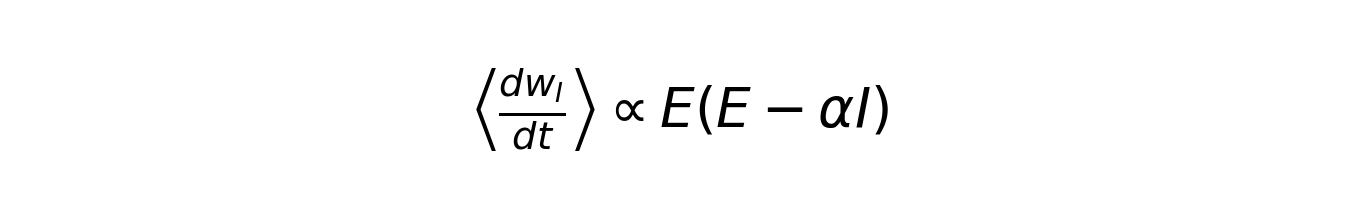</p>


따라서 fixed point는


<p align="center">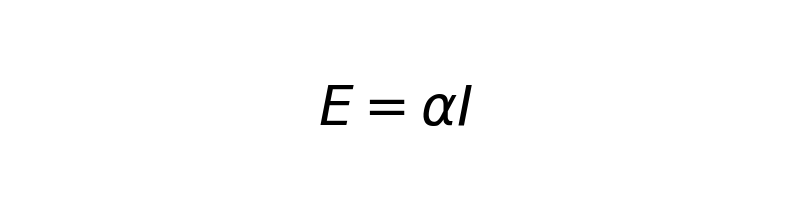</p>


이고,


<p align="center">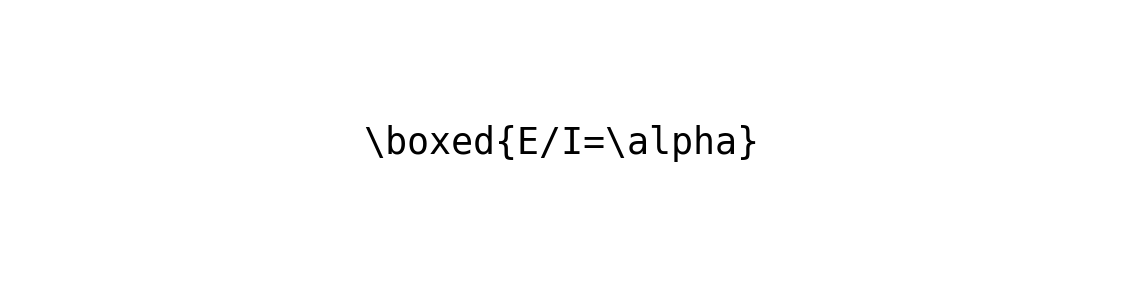</p>


입니다.

### 3단계: 그래서 Fig. 4d가 의미하는 것

Firing rate가 바뀌는 조건에서도 inhibition은 excitation을 current level에서 따라가며 balance를 맞춥니다.  
그래서 Fig. 4d에서는 spike-based E rule이 firing-rate 변화에 반응하더라도,  
co-dependent I rule이 $E/I$ balance를 유지하면서 runaway를 막습니다.

## 9. 업로드한 Brian2 코드와 연결하는 optional cell

아래 cell은 이 노트북과 같은 폴더에 `ei_balance_brian2.py`가 있을 때만 실행하면 됩니다.

업로드한 코드의 구조는 다음과 같습니다.

- `rule="spike_i"`: spike-based E + spike-based inhibitory plasticity
- `rule="codep_i"`: spike-based E + co-dependent inhibitory plasticity
- `target_rate_schedule()`은 4개 block의 target firing rate를 만듭니다.
- `balance_drive = balance_amp * E_trace * (E_trace - alpha_balance * I_trace)`가 Fig. 4의 $E(E-\alpha I)$ 항에 해당합니다.

Brian2 simulation은 시간이 조금 걸릴 수 있으므로 기본값은 `RUN_BRIAN2 = False`로 두었습니다.

In [8]:
RUN_BRIAN2 = False

if RUN_BRIAN2:
    from ei_balance_brian2 import run_one_condition

    df_spike_brian2, target_df = run_one_condition(
        rule="spike_i",
        mode="quick",
        seed_value=1,
    )

    df_codep_brian2, target_df = run_one_condition(
        rule="codep_i",
        mode="quick",
        seed_value=2,
    )

    fig, axes = plt.subplots(3, 2, figsize=(11, 8), sharex=True)

    axes[0, 0].plot(df_spike_brian2["time_min"], df_spike_brian2["firing_rate_hz"])
    axes[0, 0].set_title("Brian2: spike-based E + spike-based I")
    axes[0, 0].set_ylabel("rate (Hz)")

    axes[0, 1].plot(df_codep_brian2["time_min"], df_codep_brian2["firing_rate_hz"])
    axes[0, 1].set_title("Brian2: spike-based E + co-dependent I")

    axes[1, 0].plot(df_spike_brian2["time_min"], df_spike_brian2["ei_ratio"])
    axes[1, 0].set_ylabel("NMDA/GABA")

    axes[1, 1].plot(df_codep_brian2["time_min"], df_codep_brian2["ei_ratio"])
    axes[1, 1].axhline(0.855, linestyle="--")

    axes[2, 0].plot(df_spike_brian2["time_min"], df_spike_brian2["norm_wE"], label="E")
    axes[2, 0].plot(df_spike_brian2["time_min"], df_spike_brian2["norm_wI"], label="I")
    axes[2, 0].set_xlabel("time (min)")
    axes[2, 0].set_ylabel("normalized weight")
    axes[2, 0].legend()

    axes[2, 1].plot(df_codep_brian2["time_min"], df_codep_brian2["norm_wE"], label="E")
    axes[2, 1].plot(df_codep_brian2["time_min"], df_codep_brian2["norm_wI"], label="I")
    axes[2, 1].set_xlabel("time (min)")
    axes[2, 1].legend()

    fig.tight_layout()
    fig.savefig(OUTDIR / "06_brian2_fig4_comparison.png")
    plt.show()
else:
    print("RUN_BRIAN2 is False. Set it to True if you want to run the uploaded Brian2 model.")

RUN_BRIAN2 is False. Set it to True if you want to run the uploaded Brian2 model.


## 10. 다음 단계: Fig. 5와 Fig. 6 노트북

Fig. 5와 Fig. 6도 같은 방식으로 만들면 됩니다.

### Fig. 5 notebook에서 보여줄 수식 흐름

1. pathway별 input rate
2. disinhibition gate

<p align="center">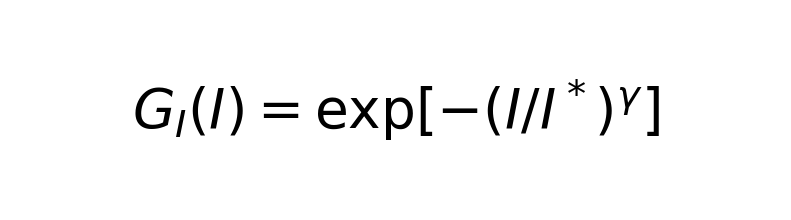</p>

3. excitatory plasticity

<p align="center">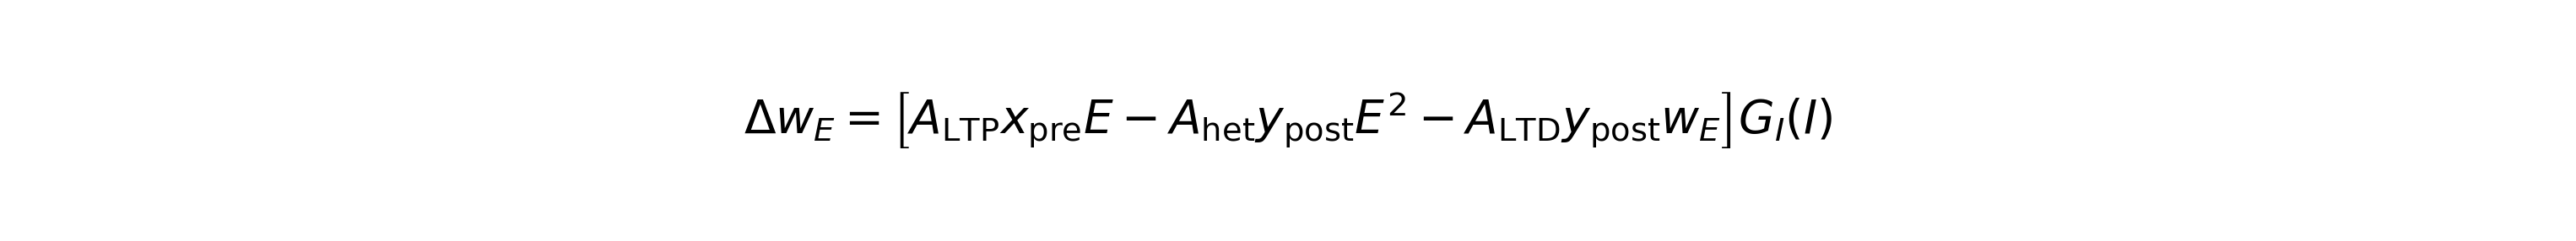</p>

4. pathway별 receptive-field profile 생성
5. inhibitory co-tuning

<p align="center">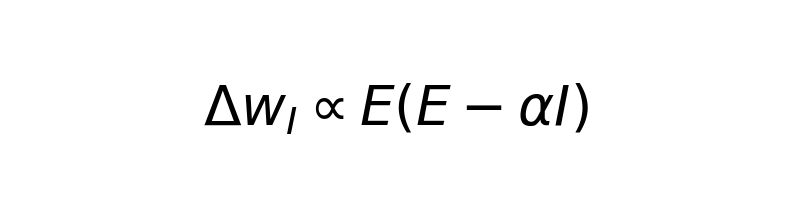</p>


### Fig. 6 notebook에서 보여줄 수식 흐름

1. soma-dendrite coupling

<p align="center">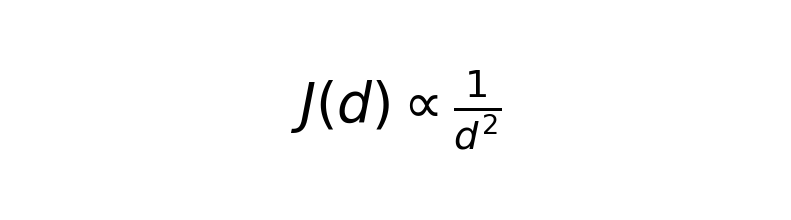</p>

2. dendritic membrane potential

<p align="center">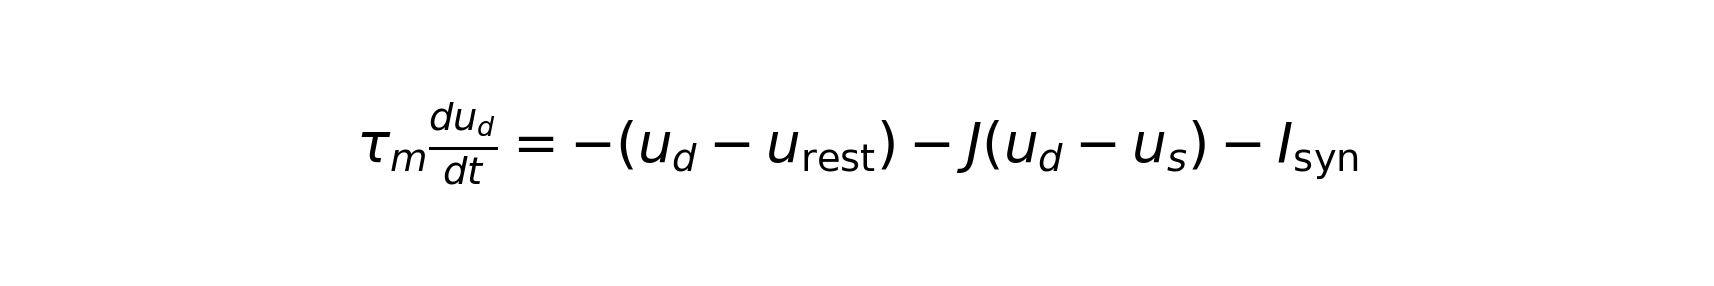</p>

3. dendritic NMDA/GABA current traces
4. co-active vs independent input competition
5. clustering index

<p align="center">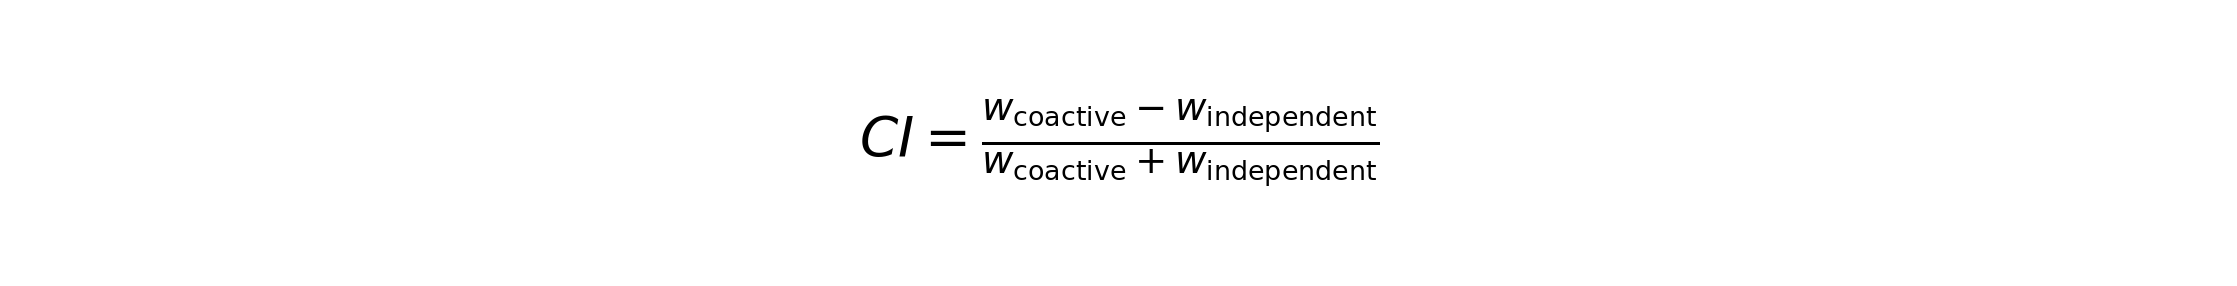</p>
